In [ ]:
import re
from collections import defaultdict

def extract_chemical_formula_moiety(file_path):
    with open(file_path, 'r') as file:
        cif_content = file.read()
    
    # Find the chemical formula moiety using regex
    pattern = r"_chemical_formula_moiety\s+['\";]([^;'\"]+)['\";]"
    match = re.search(pattern, cif_content)
    if not match:
        raise ValueError("Chemical formula moiety not found.")
    formula = match.group(1).strip()
    return formula

def parse_formula_with_quantity(formula: str):
    element_pattern = r"(\d*)\(?([A-Za-z0-9\s]+)\)?(\d*)(\d+[+-]?)"
    moieties_info = []

    for match in re.findall(element_pattern, formula):
        quantity = int(match[0]) if match[0] else 1
        elements = defaultdict(int)
        for element, count in re.findall(r"([A-Z][a-z]*)(\d*)", match[1]):
            elements[element] += int(count) if count else 1

        charge_str = match[3]
        charge = int(charge_str[:-1]) * (1 if charge_str.endswith("+") else -1)

        moieties_info.append({
            "elements": dict(elements),
            "quantity": quantity,
            "charge": charge
        })
    return moieties_info

# Example usage
file_path = "error_2/CSCNCC01/CSCNCC01.cif"
file_path = "error_2/APRCOB/APRCOB.cif"
chemical_formula = extract_chemical_formula_moiety(file_path)
moieties_info = parse_formula_with_quantity(chemical_formula)

# Display results
print("Chemical Formula Moiety:", chemical_formula)
print("Moieties Information:")
for i, moiety in enumerate(moieties_info, 1):
    print(f"Moiety {i}:")
    print(f"  Elements: {moiety['elements']}")
    print(f"  Quantity: {moiety['quantity']}")
    print(f"  Charge: {moiety['charge']}")


In [210]:
from cell2mol.cell_operations import cart2frac, frac2cart_fromparam
import numpy as np
from cell2mol.read_write import writexyz

In [207]:
newcell = np.load("error_2/APRCOB/Cell_APRCOB.cell", allow_pickle=True)

In [212]:
for idx, mol in enumerate(newcell.moleclist):
    writexyz("error_2/APRCOB", f"Mol_APRCOB_{idx}.xyz", mol.labels, mol.coord)

In [214]:
mol_0 = read('error_2/APRCOB/Mol_APRCOB_0.xyz')
mol_1 = read('error_2/APRCOB/Mol_APRCOB_1.xyz')
mol_2 = read('error_2/APRCOB/Mol_APRCOB_2.xyz')
mol_3 = read('error_2/APRCOB/Mol_APRCOB_3.xyz')

In [223]:
combined_mol = mol_0 + mol_1 + mol_2 + mol_3
combined_mol.set_cell(atoms.get_cell())

<AxesSubplot: >

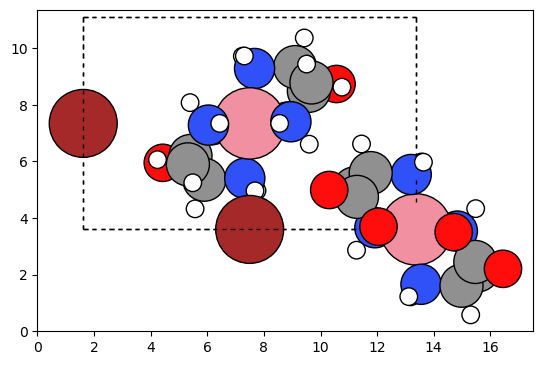

In [225]:
plot_atoms(combined_mol)

<AxesSubplot: >

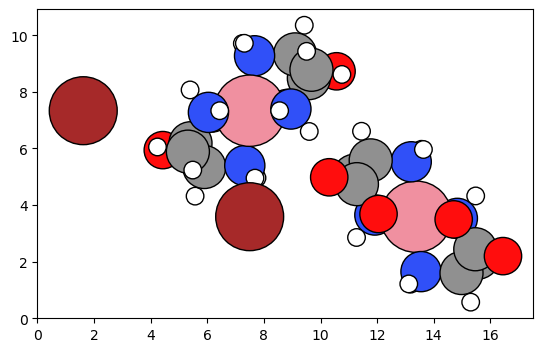

In [220]:
plot_atoms(mol_0 + mol_1 + mol_2 + mol_3)


In [ ]:
newcell.cellvec

In [ ]:
for ref in newcell.refmoleclist:
    print(cart2frac(ref.coord, newcell.cellvec))

In [ ]:
newcell.cellparam

In [ ]:
newcell.frac_coord

In [221]:
from ase.io import read
from ase.visualize.plot import plot_atoms

cif_file_path = 'error_2/APRCOB/APRCOB.cif'
atoms = read(cif_file_path)
cell = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']

 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/io/cif.py:401: UserWarning: crystal system 'orthorhombic' is not interpreted for space group Spacegroup(18, setting=1). This may result in wrong setting!
 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 12 and 16 are equivalent
 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 13 and 17 are equivalent
 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 14 and 18 are equivalent
 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 19 are equivalent
 /Users/ycho/miniconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 5 and 20 are equivale

In [174]:
atoms.get_cell()

Cell([11.76, 7.49, 5.91])

In [175]:
sym_ops = space_group.get_op()

In [176]:
sym_ops[1]

array([[0. , 0. , 0. ],
       [0.5, 0.5, 0. ],
       [0.5, 0.5, 0. ],
       [0. , 0. , 0. ]])

In [177]:
for i, (rot, trans) in enumerate(space_group.get_symop()):
    print(rot, trans)
    print("Symmetry operation #{}".format(i + 1))
    print("Rotation matrix: ", rot[0,:])
    print("                 ", rot[1,:])
    print("                 ", rot[2,:])
    print("Translation vector: ", trans)
    print()

[[1 0 0]
 [0 1 0]
 [0 0 1]] [0. 0. 0.]
Symmetry operation #1
Rotation matrix:  [1 0 0]
                  [0 1 0]
                  [0 0 1]
Translation vector:  [0. 0. 0.]

[[ 1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]] [0.5 0.5 0. ]
Symmetry operation #2
Rotation matrix:  [1 0 0]
                  [ 0 -1  0]
                  [ 0  0 -1]
Translation vector:  [0.5 0.5 0. ]

[[-1  0  0]
 [ 0  1  0]
 [ 0  0 -1]] [0.5 0.5 0. ]
Symmetry operation #3
Rotation matrix:  [-1  0  0]
                  [0 1 0]
                  [ 0  0 -1]
Translation vector:  [0.5 0.5 0. ]

[[-1  0  0]
 [ 0 -1  0]
 [ 0  0  1]] [0. 0. 0.]
Symmetry operation #4
Rotation matrix:  [-1  0  0]
                  [ 0 -1  0]
                  [0 0 1]
Translation vector:  [0. 0. 0.]



In [237]:
def apply_symmetry_operations_to_frac (molecule, cellparam, fractional_coords, sym_ops):
    new_structures = []
    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)
        normalized_positions = np.mod(transformed_positions, 1)
        new_positions = frac2cart_fromparam(normalized_positions, cellparam)
        new_molecule = molecule.copy()
        new_molecule.set_positions(new_positions)
        new_structures.append(new_molecule)
    return new_structures

<AxesSubplot: >

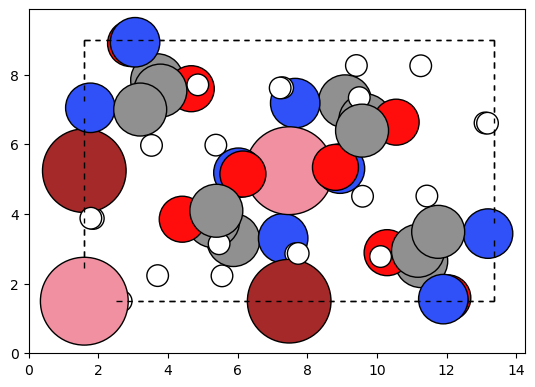

In [202]:
plot_atoms(atoms)

<AxesSubplot: >

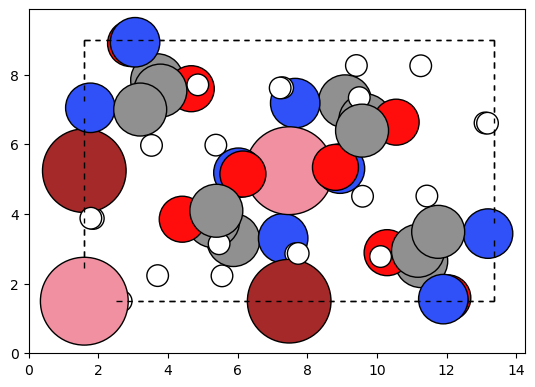

In [204]:
plot_atoms(atoms)

In [232]:
new_structures

[Atoms(symbols='BrCoC3H7N2O2N2OCH2CH2CH3O', pbc=False, cell=[11.76, 7.49, 5.91]),
 Atoms(symbols='BrCoC3H7N2O2N2OCH2CH2CH3O', pbc=False, cell=[11.76, 7.49, 5.91]),
 Atoms(symbols='BrCoC3H7N2O2N2OCH2CH2CH3O', pbc=False, cell=[11.76, 7.49, 5.91]),
 Atoms(symbols='BrCoC3H7N2O2N2OCH2CH2CH3O', pbc=False, cell=[11.76, 7.49, 5.91])]

<AxesSubplot: >

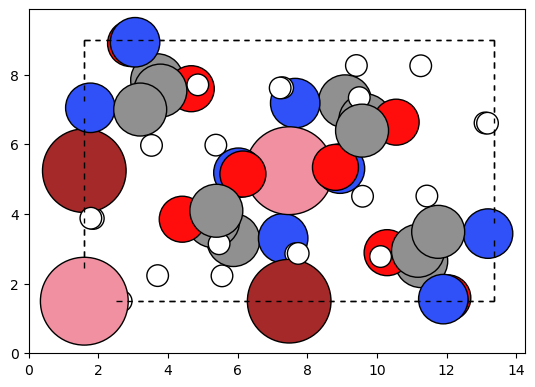

In [248]:
new_structures = apply_symmetry_operations_to_frac(cart_ref, cell, frac_ref.positions, sym_ops)
plot_atoms(new_structures[0] + new_structures[1])

<AxesSubplot: >

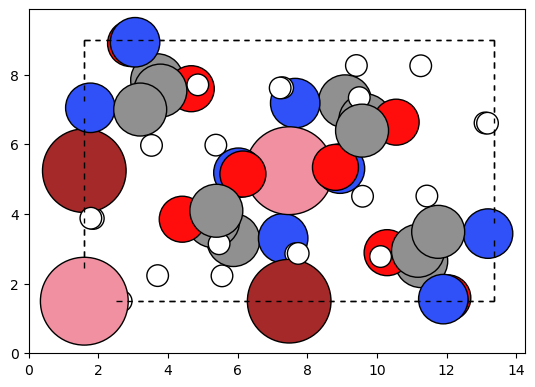

In [249]:
plot_atoms(atoms)

In [150]:
def apply_symmetry_operations(molecule, sym_ops):
    new_structures = []
    positions = molecule.get_positions()
    cell = molecule.get_cell()
    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        print(rot, trans)
        new_positions = np.dot(positions, np.transpose(rot)) + np.array(trans)# * cell.diagonal()
        new_molecule = molecule.copy()
        print(np.mean(new_positions, axis=0))
        # if is_within_unit_cell(np.mean(new_positions, axis=0), cell):
        new_molecule.set_positions(new_positions)
        new_molecule.set_cell(cell)
        new_structures.append(new_molecule)

    return new_structures

<AxesSubplot: >

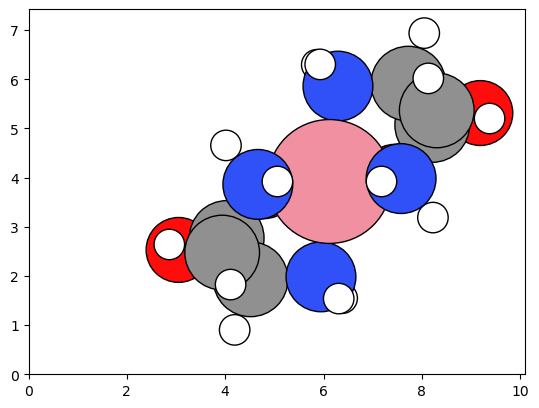

In [107]:
plot_atoms(atoms)

In [ ]:
cell

array([11.76,  7.49,  5.91, 90.  , 90.  , 90.  ])

<AxesSubplot: >

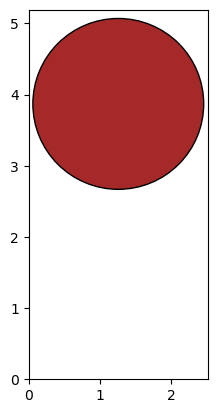

In [61]:
plot_atoms(molecule_2)

In [154]:
help(plot_atoms)

Help on function plot_atoms in module ase.visualize.plot:

plot_atoms(atoms, ax=None, **parameters)
    Plot an atoms object in a matplotlib subplot.
    
    Parameters
    ----------
    atoms : Atoms object
    ax : Matplotlib subplot object
    rotation : str, optional
        In degrees. In the form '10x,20y,30z'
    show_unit_cell : int, optional, default 2
        Draw the unit cell as dashed lines depending on value:
        0: Don't
        1: Do
        2: Do, making sure cell is visible
    radii : float, optional
        The radii of the atoms
    colors : list of strings, optional
        Color of the atoms, must be the same length as
        the number of atoms in the atoms object.
    scale : float, optional
        Scaling of the plotted atoms and lines.
    offset : tuple (float, float), optional
        Offset of the plotted atoms and lines.



[[1 0 0]
 [0 1 0]
 [0 0 1]] [0. 0. 0.]
[5.88       3.745      0.98169176]
[[ 1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]] [0.5 0.5 0. ]
[ 6.38       -3.245      -0.98169176]
[[-1  0  0]
 [ 0  1  0]
 [ 0  0 -1]] [0.5 0.5 0. ]
[-5.38        4.245      -0.98169176]
[[-1  0  0]
 [ 0 -1  0]
 [ 0  0  1]] [0. 0. 0.]
[-5.88       -3.745       0.98169176]


<AxesSubplot: >

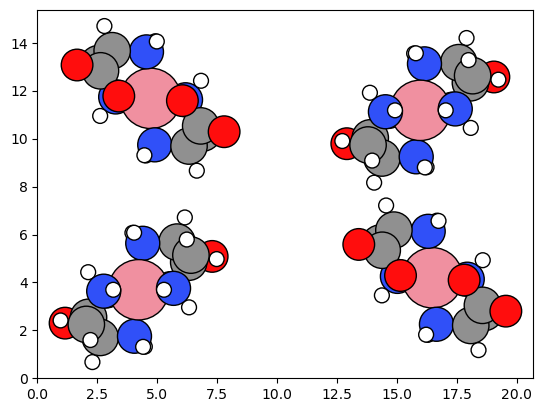

In [156]:
new_structures =apply_symmetry_operations (molecule_1, sym_ops)
new_structures
plot_atoms(molecule_1 + new_structures[1] + new_structures[2] + new_structures[3] )
# new_structures2 =apply_symmetry_operations (molecule_2, sym_ops)
# plot_atoms(molecule_1 + new_structures[1] + new_structures[2] + new_structures[3] 
#            + molecule_2 + new_structures2[1] + new_structures2[2] + new_structures2[3])

<AxesSubplot: >

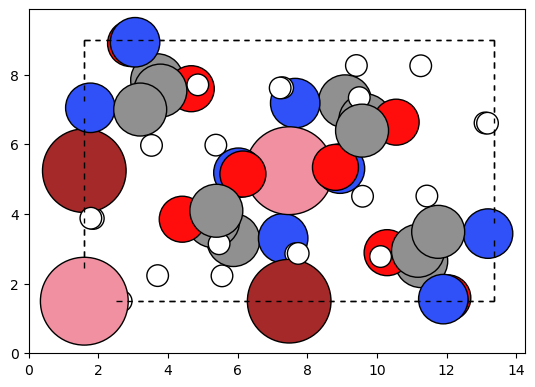

In [130]:
plot_atoms(atoms)

In [ ]:
atoms.arrays()





In [95]:
molecule_1.set_cell atoms.get_cell()

Cell([11.76, 7.49, 5.91])

In [20]:
cell

array([11.76,  7.49,  5.91, 90.  , 90.  , 90.  ])

<AxesSubplot: >

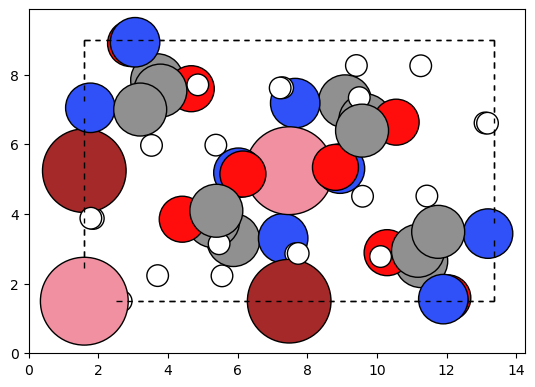

In [148]:
plot_atoms(atoms)

<AxesSubplot: >

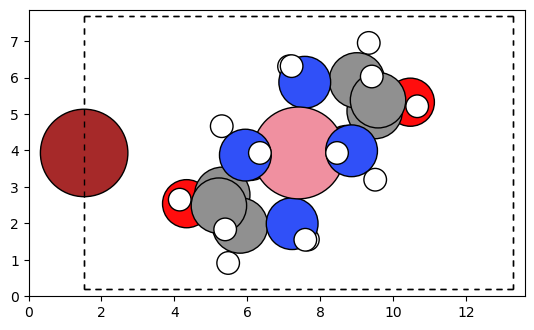

In [172]:
frac_ref = read('error_2/APRCOB/Ref_All_frac_APRCOB.xyz')
cart_ref = read('error_2/APRCOB/Ref_All_APRCOB.xyz')
cart_ref.set_cell(atoms.get_cell())
plot_atoms(cart_ref)    

In [158]:
# Load molecules from the XYZ files
molecule_1 = read('error_2/APRCOB/Ref_Molecule_APRCOB_0.xyz')
# molecule_1 = read('error_2/APRCOB/Ref_Molecule_APRCOB_frac_0.xyz')

molecule_2 = read('error_2/APRCOB/Ref_Molecule_APRCOB_1.xyz')
# molecule_2 = read('error_2/APRCOB/Ref_Molecule_APRCOB_frac_1.xyz')

molecule_1.set_cell(atoms.get_cell())
molecule_2.set_cell(atoms.get_cell())


<AxesSubplot: >

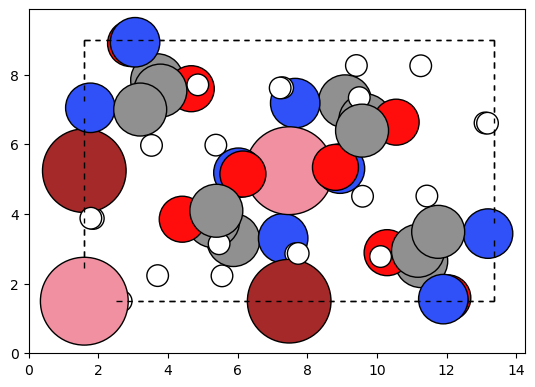

In [159]:
plot_atoms(atoms)

<AxesSubplot: >

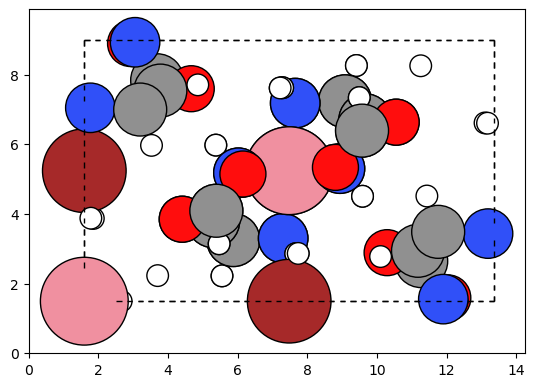

In [164]:
plot_atoms(atoms+ molecule_1)

# plot_atoms(molecule_1)
# plot_atoms(molecule_2)

In [14]:
import numpy as np
def calculate_centroid(atoms):
    positions = atoms.get_positions()
    centroid = np.mean(positions, axis=0)
    return centroid

In [16]:
calculate_centroid(molecule_2)

array([0.      , 3.745   , 2.207385])

In [21]:
# Function to check if a point is within the unit cell
def is_within_unit_cell(point, cell):
    fractional = np.linalg.solve(cell.T, point)  # Convert to fractional coordinates
    return np.all(fractional >= 0) and np.all(fractional <= 1)

In [23]:
atoms.get_cell()

Cell([11.76, 7.49, 5.91])

In [25]:
is_within_unit_cell(calculate_centroid(molecule_1), atoms.get_cell())

True

In [ ]:
is_within_unit_cell

In [ ]:
from ase.io import read
from ase import Atoms
import numpy as np

# Load molecules from the XYZ files
molecule_1 = read('error_2/APRCOB/Ref_Molecule_APRCOB_0.xyz')
molecule_2 = read('error_2/APRCOB/Ref_Molecule_APRCOB_1.xyz')

# Create the orthorhombic unit cell
cell_a = 11.76
cell_b = 7.49
cell_c = 5.91
unit_cell = Atoms(cell=[(cell_a, 0, 0), (0, cell_b, 0), (0, 0, cell_c)])

# Adding symmetry operations from space group 'P 21 21 2'
# Define symmetry operations as transformation matrices and translation vectors
sym_ops = [
    {"rot": [[1, 0, 0], [0, 1, 0], [0, 0, 1]], "trans": [0, 0, 0]},
    {"rot": [[1, 0, 0], [0, -1, 0], [0, 0, -1]], "trans": [0.5, 0.5, 0]},
    {"rot": [[-1, 0, 0], [0, 1, 0], [0, 0, -1]], "trans": [0.5, 0.5, 0]},
    {"rot": [[-1, 0, 0], [0, -1, 0], [0, 0, 1]], "trans": [0, 0, 0]}
]

# Function to apply symmetry operations to a molecule
def apply_symmetry(molecule, sym_ops, unit_cell):
    for op in sym_ops:
        rot_matrix = np.array(op["rot"])
        trans_vector = np.array(op["trans"])
        new_positions = np.dot(molecule.get_positions(), rot_matrix.T) + trans_vector * [cell_a, cell_b, cell_c]
        
        # Create new molecule instance with transformed positions
        new_molecule = molecule.copy()
        new_molecule.set_positions(new_positions)
        unit_cell += new_molecule

# Apply symmetry operations to each molecule and add to the unit cell
apply_symmetry(molecule_1, sym_ops, unit_cell)
apply_symmetry(molecule_2, sym_ops, unit_cell)

# The unit cell is now prepared with molecules positioned according to the specified symmetry
unit_cell.positions, unit_cell.get_chemical_symbols()


In [ ]:
len(unit_cell.positions)

In [ ]:
len(unit_cell.get_chemical_symbols())

In [ ]:
from ase.io import read, write
from ase.spacegroup import crystal, get_spacegroup
cif_file_path = "error_2/APRCOB/APRCOB.cif"
xyz_file_path = "error_2/APRCOB/Ref_All_APRCOB.xyz"
# Load the initial structure from CIF file
initial_structure = read(cif_file_path, format='cif')
# positions = initial_structure.get_positions('center')
# view(initial_structure, viewer='x3d')
# # Extract cell parameters and atomic positions from the CIF file
cell = initial_structure.cell.cellpar()
# # symbols = initial_structure.get_chemical_symbols()
# # positions = initial_structure.get_positions()
print(cell)
space_group = initial_structure.info['spacegroup']
print(space_group)
# crystal_structure = crystal(symbols=initial_structure.get_chemical_symbols(),
#                             basis=initial_structure.get_positions(),
#                             spacegroup=space_group,
#                             cellpar=cell)

# view(crystal_structure)

In [ ]:
supercell_size=[[2, 0, 0], [0, 1, 0], [0, 0, 1]]
supercell = make_supercell(initial_structure, supercell_size)
view(supercell, viewer='x3d')


In [ ]:
from ase.build import molecule, make_supercell
from ase.spacegroup import crystal
from ase.visualize import view

# Define the molecular structure (e.g., water)
molecule = molecule('H2O')

# Create a supercell to fill the unit cell
supercell = make_supercell(molecule, [[3, 0, 0], [0, 3, 0], [0, 0, 3]])

# Define lattice parameters and space group (e.g., cubic cell with P1 symmetry)
a = b = c = 10  # lattice parameters
spacegroup = 1  # P1 symmetry

# Create a crystal object representing the filled unit cell
unit_cell = crystal(symbols=supercell.get_chemical_symbols(),
                    basis=supercell.get_positions(),
                    spacegroup=spacegroup,
                    cellpar=[a, b, c, 90, 90, 90],symprec=1e-5)

# Optionally, visualize the filled unit cell
view(unit_cell)


In [ ]:
from ase.visualize import view

# Create a molecule (e.g., water)
atoms = molecule('H2O')

# Optionally, visualize the original molecule
view(atoms, viewer='x3d')

# Ensure that molecules are not fragmented
atoms.wrap()

# Optionally, visualize the unit cell after wrapping
view(atoms, viewer='x3d')

In [ ]:
import matplotlib.pyplot as plt

from ase.visualize import view
from ase.visualize.plot import plot_atoms
plot_atoms(crystal_structure)
# crystal_structure.get_positions("center")
view(crystal_structure, viewer='x3d')

In [ ]:
help(crystal_structure.wrap)

In [ ]:
help(view)

In [ ]:
cell

In [ ]:
space_group, space_group.no, space_group.symbol

In [ ]:
# Access symmetry operations
symmetry_operations = space_group.get_symop()
for op in symmetry_operations:
    print(op)

In [ ]:
for i, (rot, trans) in enumerate(space_group.get_symop()):
    print("Symmetry operation #{}".format(i + 1))
    print("Rotation matrix: ", rot[0,:])
    print("                 ", rot[1,:])
    print("                 ", rot[2,:])
    print("Translation vector: ", trans)
    print()

In [ ]:
help(space_group.equivalent_sites)

In [ ]:
newcell

In [ ]:
for label, fcoord, ccoord in zip(newcell.labels, newcell.frac_coord, newcell.coord):
    if label == "Br":
        print(label, fcoord, ccoord)

In [ ]:
help(space_group)

In [ ]:
from cell2mol.read_write import writexyz


In [ ]:
for idx, ref in enumerate(newcell.refmoleclist):
    print(ref.formula)
    frac_coord = cart2frac(ref.coord, newcell.cellvec)
    # print(space_group.symmetry_normalised_sites(frac_coord))
    sites, kind = space_group.equivalent_sites(frac_coord, onduplicates='keep')
    # for i, (label, fcoord) in enumerate(zip(ref.labels, frac_coord)):   
    #     print(i, label, fcoord)
    # #     sites, kind = space_group.equivalent_sites(fcoord)
    # #     if label == "Br":
    # # print(frac_coord)
    # print(kind)
    cart_coords = frac2cart_fromparam(np.array(sites), newcell.cellparam)
    new_labels = [ref.labels[i] for i in kind]
    writexyz("error_2/APRCOB", f"Ref_frac_APRCOB_{idx}.xyz", new_labels, cart_coords)
#     for site, ccord, i in zip(sites, cart_coords, kind):
#       #     print(site)
#           print(i, ref.labels[i], site, ccord)
    # # print(len(ref.labels), len(sites), len(kind))
    # # for label, fcoord in zip(ref.labels, frac_coord):   

    print(len(ref.labels), len(sites), len(kind))
    # # print(sites, kind)
    # print("---")

In [ ]:
labels = atoms.get_chemical_symbols(),
positions = atoms.positions

In [ ]:
sym_ops_cartesian

In [ ]:
labels

In [ ]:
positions

In [ ]:
# List to collect all transformed structures and their labels
all_transformed_positions = []
all_labels = []

# Apply all symmetry operations
for rot_cart, trans_cart in sym_ops_cartesian:
    transformed_positions = (rot_cart @ positions.T + trans_cart[:, np.newaxis]).T
    all_transformed_positions.append(transformed_positions)
    all_labels.append(labels)  # Copy labels directly since symmetry operations don't alter the type of atoms



In [ ]:
sym_ops_cartesian

In [ ]:
len(all_labels)

In [ ]:
from cell2mol.read_write import writexyz

In [ ]:
import os

In [ ]:
os.

In [ ]:
for idx, (lab, pos) in enumerate(zip(all_labels, all_transformed_positions)):
    writexyz("error_2/BOFFOS", f"BOFFOS_symmetry_operation_{idx}.xyz", lab[0], pos)
    print(lab[0])
    print(pos)

In [ ]:
len(all_transformed_positions)

In [ ]:
transformed_positions

In [ ]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
plot_atoms(initial_structure)

In [ ]:
atoms.get_scaled_positions()

In [ ]:
# Load your initial atomic positions; assuming these are stored in an XYZ file
atoms = read(xyz_file_path, format='xyz')

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=atoms.get_chemical_symbols(),
                            basis=atoms.get_positions(),
                            spacegroup=space_group,
                            cellpar=cell)

# # # Save the complete structure to a new XYZ file
# cell_xyz_file_path = "error_2/BOFFOS/BOFFOS_complete_structure.xyz"
# write(cell_xyz_file_path, crystal_structure, format='xyz')

# print(f"XYZ file with complete structure saved as {xyz_file_path}")

In [ ]:
plot_atoms(atoms)

In [ ]:
plot_atoms(crystal_structure)

In [ ]:
from ase.visualize import view


In [ ]:
view(atoms)

In [ ]:
len(atoms)

In [ ]:
atoms.get_positions()

In [ ]:
from ase import Atoms
from ase.io import read, write
from ase.spacegroup import crystal

# Define the unit cell parameters
a = 24.369  # Lattice constant a
c = 9.748   # Lattice constant c
cell = [a, a, c, 90, 90, 120]  # Rhombohedral cell parameters
spacegroup = 'R3'  # Space group 'R 3'

# Load your initial atomic positions; assuming these are stored in an XYZ file
atoms = read('path_to_your_file.xyz', format='xyz')

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=atoms.get_chemical_symbols(),
                            basis=atoms.get_positions(),
                            spacegroup=spacegroup,
                            cellpar=cell)

# Save the complete structure to a new XYZ file
xyz_file_path = 'complete_structure.xyz'
write(xyz_file_path, crystal_structure, format='xyz')

print(f"XYZ file with complete structure saved as {xyz_file_path}")


In [ ]:
help(ase.io.read)

In [ ]:
atoms = ase.io.read(input_path)

In [ ]:
atoms[0]

In [ ]:
atoms[59]

In [ ]:
atoms._get_cell()

In [ ]:
import ase.structure


ase.structur

In [ ]:
import ase.spacegroup


help(ase.spacegroup)

In [ ]:
from ase.io import read, write
from ase.spacegroup import crystal

# Path to your CIF file
cif_file_path = 'path_to_your_cif_file.cif'

# Load the initial structure from CIF file
initial_structure = read(cif_file_path, format='cif')

# Extract cell parameters and atomic positions from the CIF file
cell = initial_structure.cell.cellpar()
symbols = initial_structure.get_chemical_symbols()
positions = initial_structure.get_positions()
spacegroup = 'R3'  # Space group 'R 3', make sure it matches the CIF space group if different

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=symbols,
                            basis=positions,
                            spacegroup=spacegroup,
                            cellpar=cell)

# Save the complete structure to an XYZ file
xyz_file_path = 'complete_structure.xyz'
write(xyz_file_path, crystal_structure, format='xyz')

print(f"XYZ file with complete structure saved as {xyz_file_path}")


In [ ]:
import numpy as np
import gemmi

In [ ]:
import numpy as np
import gemmi
import re

def clean_number(string):
    # Remove uncertainty parentheses
    return re.sub(r'\(.*\)', '', string)

def read_cif(cif_path):
    doc = gemmi.cif.read_file(cif_path)
    block = doc.sole_block()

    # Extract unit cell parameters with uncertainties removed
    cell = gemmi.UnitCell(
        float(clean_number(block.find_value('_cell_length_a'))),
        float(clean_number(block.find_value('_cell_length_b'))),
        float(clean_number(block.find_value('_cell_length_c'))),
        float(clean_number(block.find_value('_cell_angle_alpha'))),
        float(clean_number(block.find_value('_cell_angle_beta'))),
        float(clean_number(block.find_value('_cell_angle_gamma')))
    )

    # Extract symmetry operations
    symmetry_ops = []
    sym_loop = block.find_loop('_symmetry_equiv_pos_as_xyz')
    for op in sym_loop:
        symmetry_ops.append(op)

    return cell, symmetry_ops

def convert_symmetry_to_cartesian(cell, symmetry_ops):
    # Create transformation matrix from fractional to Cartesian
    to_cartesian = np.array(cell.orthogonalization_matrix).reshape(3, 3)
    to_fractional = np.linalg.inv(to_cartesian)

    cartesian_ops = []
    for op in symmetry_ops:
        # Parse the operation using gemmi
        mat, vec = gemmi.cif.parse_symop(op)
        rot_matrix_frac = np.array(mat.mat).reshape(3, 3)
        trans_vector_frac = np.array(vec)

        # Convert rotation and translation to Cartesian
        rot_matrix_cart = np.dot(to_cartesian, np.dot(rot_matrix_frac, to_fractional))
        trans_vector_cart = np.dot(to_cartesian, trans_vector_frac)

        cartesian_ops.append((rot_matrix_cart, trans_vector_cart))

    return cartesian_ops

# Path to the CIF file
cif_path = "error_2/BOFFOS/BOFFOS.cif"

# Process the CIF file
cell, symmetry_ops = read_cif(cif_path)
cartesian_ops = convert_symmetry_to_cartesian(cell, symmetry_ops)

# Print the converted Cartesian symmetry operations
for i, op in enumerate(cartesian_ops, 1):
    print(f"Operation {i}: Rotation Matrix\n{op[0]}\nTranslation Vector\n{op[1]}\n")


In [ ]:
gemmi